In [10]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

# Projeto 2 - Sinais e Sistemas em Tempo Discreto - 2026/01
# Identificação
## Nome: Raul Myron Silva Amorim
## Matrícula: 200049712

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [14]:
def plot_pz(zeros, polos, titulo="Diagrama de polos e zeros", ax=None):
    """Desenha o diagrama de polos e zeros com a circunferência unitária."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.6)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    if len(zeros) > 0:
        ax.scatter(np.real(zeros), np.imag(zeros),
                   marker='o', s=90, facecolors='none', edgecolors='tab:blue', label='Zeros')
    if len(polos) > 0:
        ax.scatter(np.real(polos), np.imag(polos),
                   marker='x', s=90, color='tab:red', label='Polos')
    ax.set_xlabel("Re{z}")
    ax.set_ylabel("Im{z}")
    ax.set_title(titulo)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')
    return ax


def resp_freq(b, a, fs, npts=2048, titulo=""):
    """Plota magnitude e fase de H(e^{jw})."""
    w, H = sp.signal.freqz(b, a, worN=npts, fs=fs)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5))
    ax1.plot(w, 20*np.log10(np.abs(H) + 1e-12))
    ax1.set_ylabel("|H(f)| [dB]")
    ax1.set_title(titulo)
    ax1.grid(alpha=0.3)
    ax2.plot(w, np.unwrap(np.angle(H)))
    ax2.set_xlabel("Frequência [Hz]")
    ax2.set_ylabel("Fase [rad]")
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    return w, H

# Questão 1

Um sistema de aquisição de dados de eletrocardiograma foi ligado de forma equivocada perto demais da rede elétrica. Assim, a interferência da rede elétrica (a 60 Hz) aparece de forma marcante no sinal adquirido. O seu objetivo é projetar um filtro digital para eliminar totalmente o ruído em 60Hz. A frequência de amostragem do sistema é: 

$$ f_a = 500~Hz $$ 

Siga as questões abaixo.

## Questão 1a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

<img src="2.1a.jpeg" width="600">

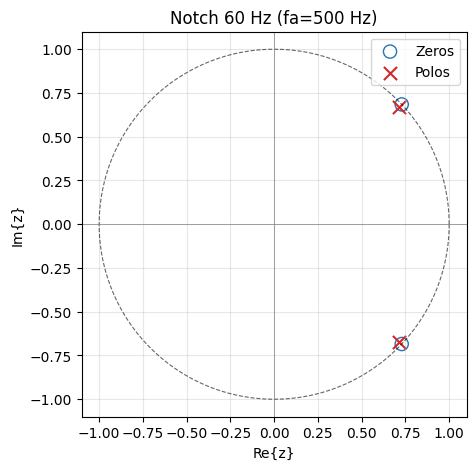

In [15]:
#Resposta da questão 1a

fa = 500
f0 = 60
w0 = 2*np.pi*f0/fa
r = 0.98

zeros_q1 = np.array([np.exp(1j*w0), np.exp(-1j*w0)])
polos_q1 = np.array([r*np.exp(1j*w0), r*np.exp(-1j*w0)])

plot_pz(zeros_q1, polos_q1, titulo="Notch 60 Hz (fa=500 Hz)")
plt.show()

## Questão 1b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo.

<img src="imagens/2.1b.jpeg" width="600">

In [16]:
#Resposta da questão 1b

b_q1 = np.array([1.0, -2*np.cos(w0), 1.0])
a_q1 = np.array([1.0, -2*r*np.cos(w0), r**2])

print("b =", b_q1)
print("a =", a_q1)

b = [ 1.         -1.45793725  1.        ]
a = [ 1.         -1.42877851  0.9604    ]


## Questão 1c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase). 

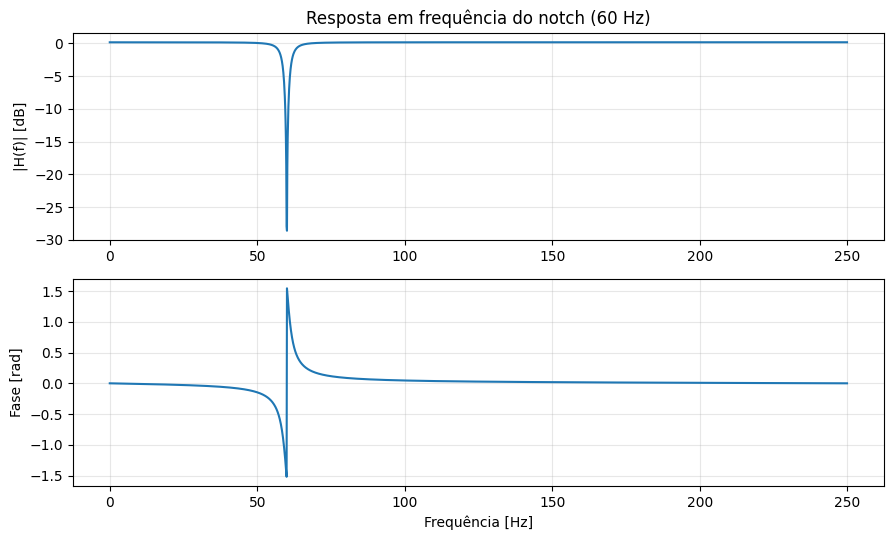

In [17]:
#Resposta da questão 1c

resp_freq(b_q1, a_q1, fa, titulo="Resposta em frequência do notch (60 Hz)")
plt.show()

## Questão 1d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

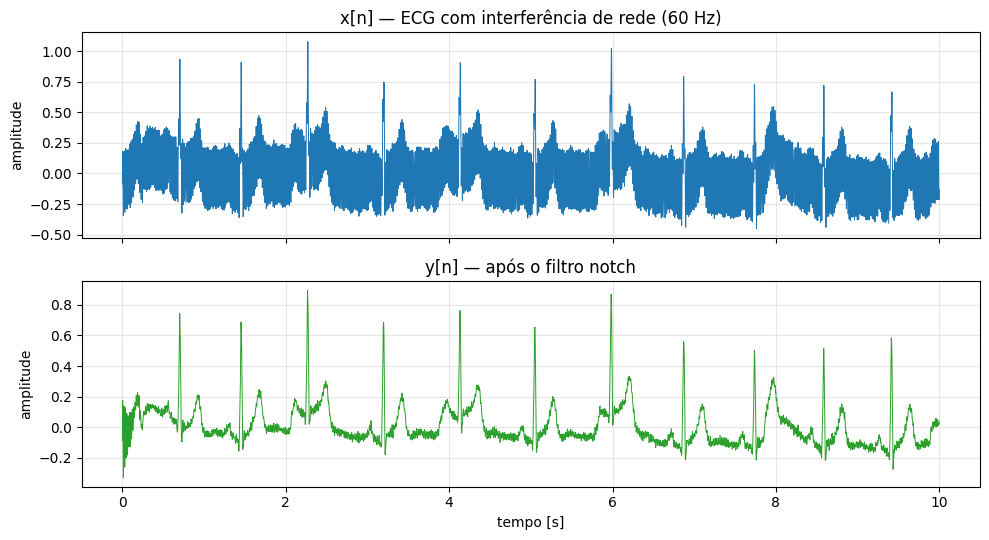

In [19]:
#Resposta da questão 1d

sinal = sp.io.loadmat('noisy_ecg_data.mat')['noisy_ecg'].ravel()

sinal = sp.io.loadmat('noisy_ecg_data.mat')['noisy_ecg'].ravel()

filtrado = sps.lfilter(b_q1, a_q1, sinal)
n = np.arange(len(sinal))
t = n / fa

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(t, sinal, lw=0.7)
axes[0].set_title("x[n] — ECG com interferência de rede (60 Hz)")
axes[0].set_ylabel("amplitude")
axes[0].grid(alpha=0.3)
axes[1].plot(t, filtrado, lw=0.7, color='tab:green')
axes[1].set_title("y[n] — após o filtro notch")
axes[1].set_xlabel("tempo [s]")
axes[1].set_ylabel("amplitude")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Questão 2

Ainda no sistema de aquisição de dados de eletrocardiograma, mais tarde foi verificado que, mesmo depois de resolvido o problema da interferência da rede elétrica (i.e., o sinal não tem um ruído específico em 60Hz), o sinal adquirido tinha bastante ruído de alta frequência (acima de 35Hz). O objetivo desta questão é projetar um filtro digital para atenuar as frequências acima de 35Hz. A frequêencia de amostragem do sistema é:

$$ f_a = 500~Hz $$

Siga as questões abaixo.

## Questão 2a (0.5  pontos)

Projete o filtro em questão utilizando a colocação de pólos e zeros no plano z. Desenhe o diagrama de pólos e zeros do filtro projetado, indicando quais pólos e zeros foram indicados e o porquê destes pólos/zeros terem sido escolhidos. Você pode inserir o seu projeto como uma imagem escaneada abaixo.

Quero um filtro passa-baixas que atenue conteúdo acima de 35 Hz, com $f_a = 500$ Hz. A frequência normalizada de corte é:

$$\omega_c = 2\pi \frac{35}{500} = 0{,}14\pi \approx 0{,}44 \text{ rad/amostra}$$

Zeros em $z = -1$ (duplo): o ponto $z=-1$ na circunferência unitária corresponde a $\omega = \pi$, ou seja, $f_a/2 = 250$ Hz (a frequência mais alta representável). Colocar zeros aí garante atenuação total no extremo superior do espectro. Uso zero duplo para que a atenuação cresça mais rápido conforme nos aproximamos de $\pi$, reforçando a rejeição acima de 35 Hz.

Polos reais em $z = r$ (duplo), com $r = 0{,}80$:** o ponto $z = +1$ na circunferência unitária corresponde a $\omega = 0$ (DC). Polos reais e positivos próximos de 1 puxam o ganho para cima nas baixas frequências, criando o comportamento passa-baixas desejado. A escolha do raio controla o joelho do filtro: $r$ mais perto de 1 → corte mais baixo (vala mais estreita); $r$ menor → corte mais alto e transição mais suave. Adoto $r = 0{,}80$ como ponto de partida que posiciona a região de -3 dB próxima dos 35 Hz; o valor pode ser refinado observando a resposta em frequência.

Uso polo duplo para casar a ordem do numerador (e dar mais inclinação na banda de transição). Como $|r| = 0{,}80 < 1$, o filtro é estável.

Por fim, normalizo o ganho em DC para 1 (constante $K$ calculada na questão seguinte), garantindo que o sinal útil em baixas frequências não seja amplificado nem atenuado pelo filtro.

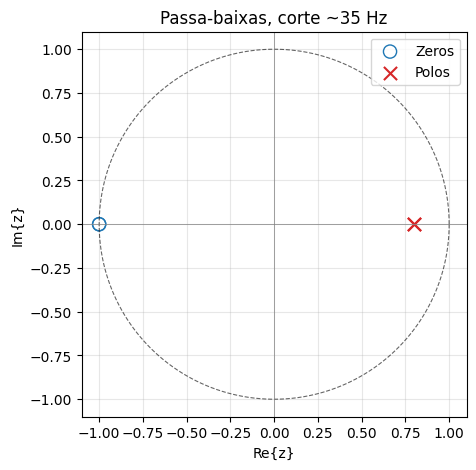

In [21]:
#Resposta da questão 2a

fa2 = 500
fc = 35

r2 = 0.80
zeros_q2 = np.array([-1.0, -1.0])
polos_q2 = np.array([r2, r2])

plot_pz(zeros_q2, polos_q2, titulo="Passa-baixas, corte ~35 Hz")
plt.show()

## Questão 2b (0.5 pontos)

A partir do diagrama desenvolvido na questão anterior, escreva a função de transferência do filtro H(z) e a equação de diferenças do sistema que realiza o filtro. Você pode inserir sua resposta como uma imagem escaneada abaixo


Da configuração escolhida (zero duplo em $z=-1$, polo duplo em $z=r$):

$$H(z) = K\,\frac{(z+1)^2}{(z-r)^2} = K\,\frac{1 + 2z^{-1} + z^{-2}}{1 - 2r\,z^{-1} + r^2 z^{-2}}$$

Normalizando o ganho em DC ($z=1$) para 1:

$$H(1) = K\,\frac{(1+1)^2}{(1-r)^2} = K\,\frac{4}{(1-r)^2} = 1 \;\Rightarrow\; K = \frac{(1-r)^2}{4}$$

Com $r = 0{,}80$: $K = (0{,}2)^2/4 = 0{,}01$.

**Equação de diferenças:**

$$y[n] = K\,\bigl(x[n] + 2x[n-1] + x[n-2]\bigr) + 2r\,y[n-1] - r^2\,y[n-2]$$

In [22]:
#Resposta da questão 2b

K = (1 - r2)**2 / 4
b_q2 = K * np.array([1.0, 2.0, 1.0])
a_q2 = np.array([1.0, -2*r2, r2**2])

print("K =", K)
print("b =", b_q2)
print("a =", a_q2)

K = 0.009999999999999995
b = [0.01 0.02 0.01]
a = [ 1.   -1.6   0.64]


## Questão 2c (1  ponto)

Plote a **resposta em frequência** do filtro projetado (magnitude e fase). 

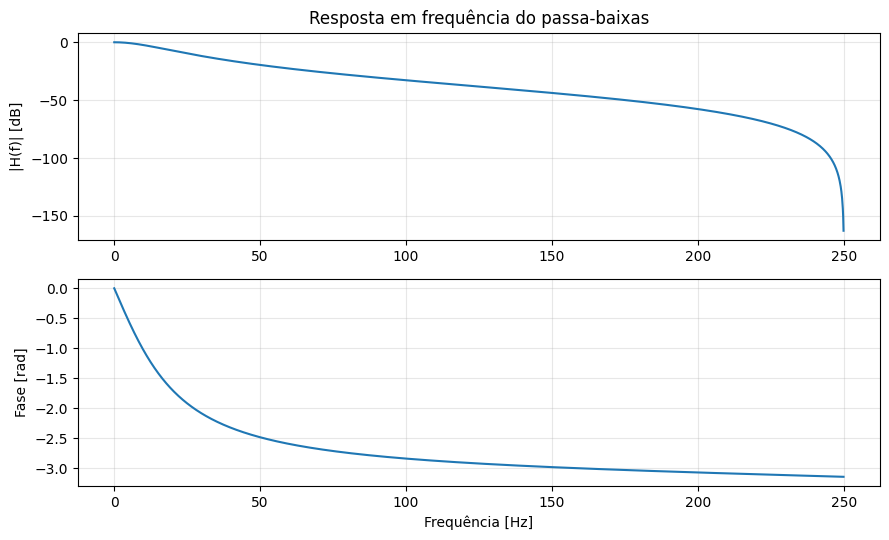

Frequência de -3 dB ≈ 11.35 Hz


In [23]:
#Resposta da questão 2c

resp_freq(b_q2, a_q2, fa2, titulo="Resposta em frequência do passa-baixas")
plt.show()

# verificação: onde fica o -3 dB?
w, H = sps.freqz(b_q2, a_q2, worN=4096, fs=fa2)
mag_db = 20*np.log10(np.abs(H) + 1e-12)
idx = np.argmin(np.abs(mag_db - (-3)))
print(f"Frequência de -3 dB ≈ {w[idx]:.2f} Hz")

## Questão 2d (0.5  pontos)

Carregue o sinal de ECG "noisy_ecg_data_2.mat" e aplique o filtro projetado neste sinal. Plote o sinal antes da filtragem (x[n]) e o sinal após a filtragem (y[n]).

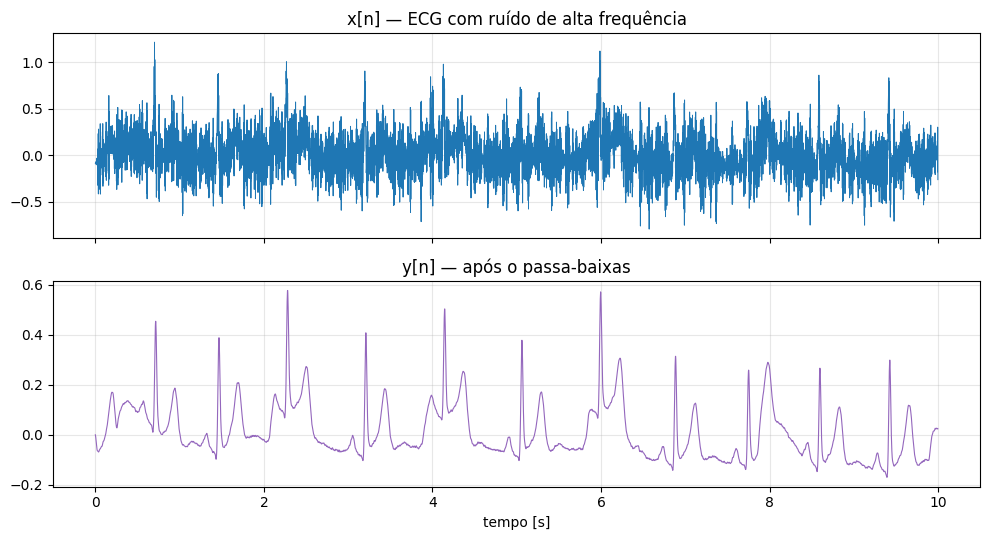

In [24]:
#Resposta da questão 2d

sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

y2 = sps.lfilter(b_q2, a_q2, sinal)
t = np.arange(len(sinal)) / fa2

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(t, sinal, lw=0.7)
axes[0].set_title("x[n] — ECG com ruído de alta frequência")
axes[0].grid(alpha=0.3)
axes[1].plot(t, y2, lw=0.8, color='tab:purple')
axes[1].set_title("y[n] — após o passa-baixas")
axes[1].set_xlabel("tempo [s]")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Questão 3

Considere o filtro analógico:

$$ H_a \left(s\right) = \frac{\omega_c}{\omega_c + s}$$

E considere o valor:

$$\omega_c = 10^3 $$

## Questão 3a (1  ponto)

Projete uma aproximação digital para este filtro com critério de 10%. Indique a taxa de amostragem calculada para esta aproximação (T1) e compare a resposta em frequência do filtro projetado H1() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

wmax (10%) = 9949.87 rad/s
T1 = 3.157e-04 s   (fs1 = 3167.14 Hz)


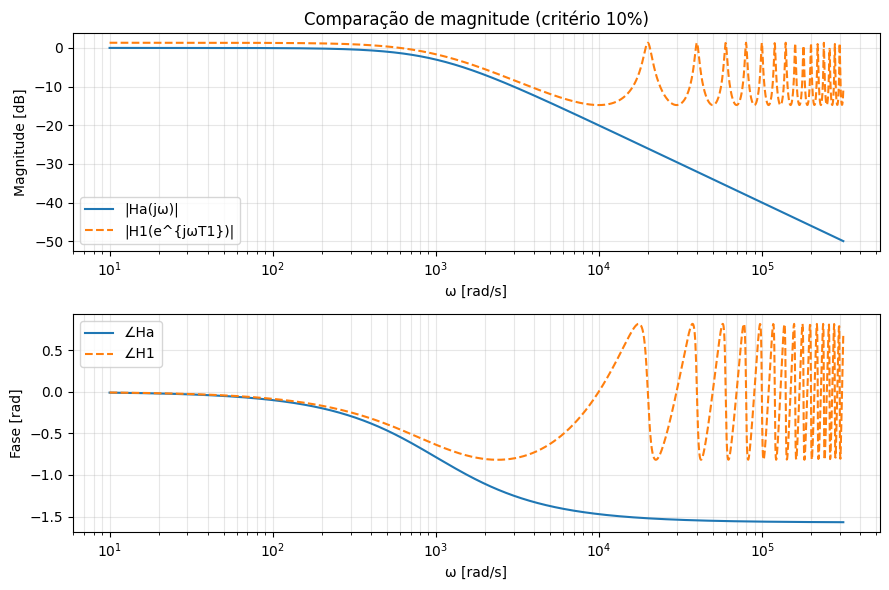

In [26]:
#Resposta da questão 3a

wc = 1e3

# critério 10%
alpha1 = 0.10
wmax1 = wc * np.sqrt(1/alpha1**2 - 1)
T1 = np.pi / wmax1
print(f"wmax (10%) = {wmax1:.2f} rad/s")
print(f"T1 = {T1:.3e} s   (fs1 = {1/T1:.2f} Hz)")

# filtro digital por invariância ao impulso
b1 = np.array([T1*wc])
a1 = np.array([1.0, -np.exp(-wc*T1)])

# comparação em frequência
w_cont = np.logspace(1, np.log10(1e5*np.pi), 2000)
Ha = wc / (1j*w_cont + wc)

w_dig, H1 = sps.freqz(b1, a1, worN=w_cont*T1)  # w em rad/amostra = w_analog*T
# converto eixo de volta para rad/s analógico
w_eq = w_dig / T1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
ax1.semilogx(w_cont, 20*np.log10(np.abs(Ha)), label="|Ha(jω)|")
ax1.semilogx(w_eq, 20*np.log10(np.abs(H1) + 1e-15), '--', label="|H1(e^{jωT1})|")
ax1.set_xlabel("ω [rad/s]")
ax1.set_ylabel("Magnitude [dB]")
ax1.set_title("Comparação de magnitude (critério 10%)")
ax1.grid(alpha=0.3, which='both')
ax1.legend()

ax2.semilogx(w_cont, np.unwrap(np.angle(Ha)), label="∠Ha")
ax2.semilogx(w_eq, np.unwrap(np.angle(H1)), '--', label="∠H1")
ax2.set_xlabel("ω [rad/s]")
ax2.set_ylabel("Fase [rad]")
ax2.grid(alpha=0.3, which='both')
ax2.legend()
plt.tight_layout()
plt.show()

## Questão 3b (1  ponto)

Projete uma aproximação digital para este filtro com critério de 1%. Indique a taxa de amostragem calculada para esta aproximação (T2) e compare a resposta em frequência do filtro projetado H2() com a resposta em frequência do filtro analógic Ha(). Plote as frequências até ao menos:

$$ \omega = 10^5 \pi $$

wmax (1%) = 99995.00 rad/s
T2 = 3.142e-05 s   (fs2 = 31829.40 Hz)


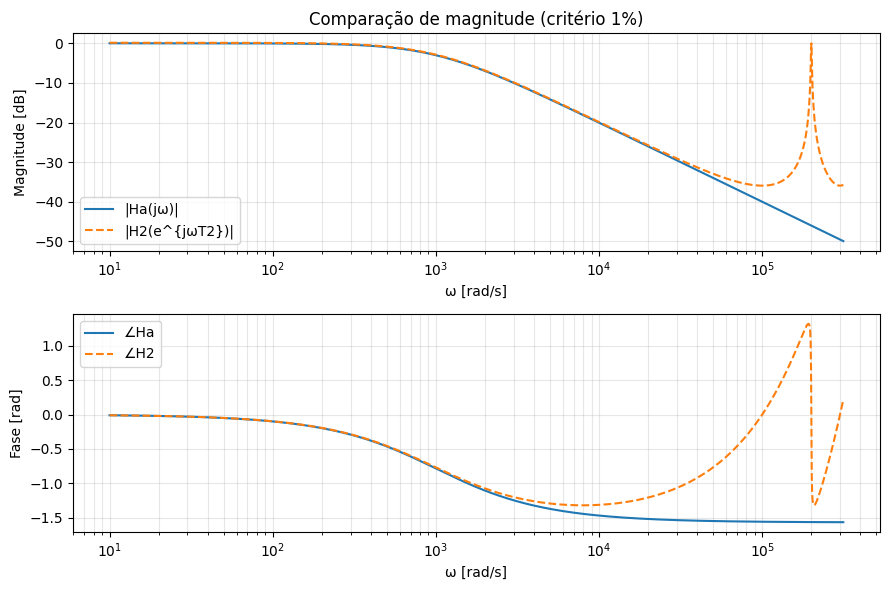

In [27]:
#Resposta da questão 3b

alpha2 = 0.01
wmax2 = wc * np.sqrt(1/alpha2**2 - 1)
T2 = np.pi / wmax2
print(f"wmax (1%) = {wmax2:.2f} rad/s")
print(f"T2 = {T2:.3e} s   (fs2 = {1/T2:.2f} Hz)")

b2 = np.array([T2*wc])
a2 = np.array([1.0, -np.exp(-wc*T2)])

w_dig2, H2 = sps.freqz(b2, a2, worN=w_cont*T2)
w_eq2 = w_dig2 / T2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
ax1.semilogx(w_cont, 20*np.log10(np.abs(Ha)), label="|Ha(jω)|")
ax1.semilogx(w_eq2, 20*np.log10(np.abs(H2) + 1e-15), '--', label="|H2(e^{jωT2})|")
ax1.set_xlabel("ω [rad/s]")
ax1.set_ylabel("Magnitude [dB]")
ax1.set_title("Comparação de magnitude (critério 1%)")
ax1.grid(alpha=0.3, which='both')
ax1.legend()

ax2.semilogx(w_cont, np.unwrap(np.angle(Ha)), label="∠Ha")
ax2.semilogx(w_eq2, np.unwrap(np.angle(H2)), '--', label="∠H2")
ax2.set_xlabel("ω [rad/s]")
ax2.set_ylabel("Fase [rad]")
ax2.grid(alpha=0.3, which='both')
ax2.legend()
plt.tight_layout()
plt.show()

## Questão 3c (1 ponto)

Calcule a resposta ao impulso ha(t) do filtro analógico Ha(s), bem como as respostas ao impulso h1[n] e h2[n] dos filtros projetados H1(z) e H2(z). **Plote** as respostas ao impulso na mesma escala.

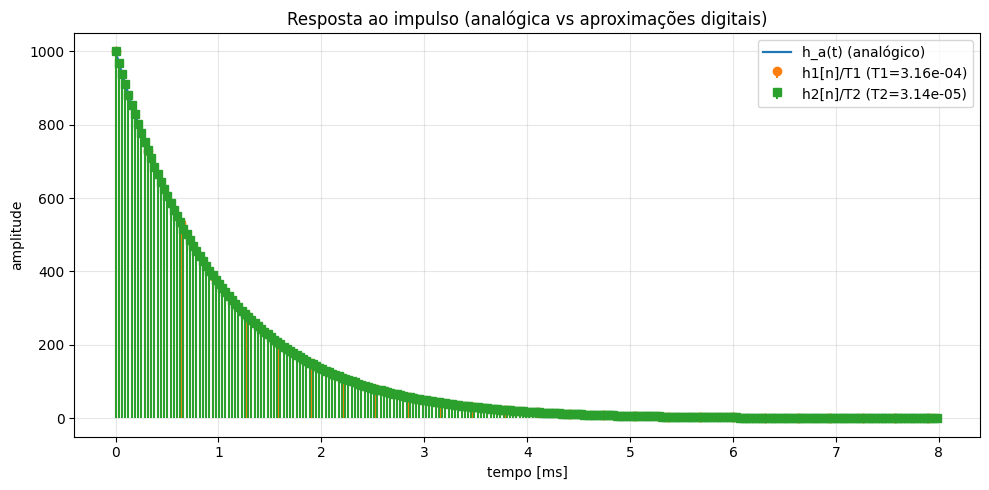

In [28]:
#Resposta da questão 3c

# eixo de tempo contínuo
t_cont = np.linspace(0, 8e-3, 2000)
ha = wc * np.exp(-wc*t_cont)

# impulsos digitais
N1 = int(np.ceil(8e-3 / T1))
N2 = int(np.ceil(8e-3 / T2))
n1 = np.arange(N1)
n2 = np.arange(N2)
h1n = T1*wc * np.exp(-wc*T1*n1)
h2n = T2*wc * np.exp(-wc*T2*n2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_cont*1e3, ha, label="h_a(t) (analógico)", lw=1.6)
# escalo dividindo por T para colocar tudo na mesma "altura física"
ax.stem(n1*T1*1e3, h1n/T1, linefmt='C1-', markerfmt='C1o', basefmt=' ',
        label=f"h1[n]/T1 (T1={T1:.2e})")
ax.stem(n2*T2*1e3, h2n/T2, linefmt='C2-', markerfmt='C2s', basefmt=' ',
        label=f"h2[n]/T2 (T2={T2:.2e})")
ax.set_xlabel("tempo [ms]")
ax.set_ylabel("amplitude")
ax.set_title("Resposta ao impulso (analógica vs aproximações digitais)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Questão 3d (2 pontos)

Considere o sinal:
$$ x\left(t\right) = e^{- \lambda t} u\left(t\right)$$

com

$$\lambda = 500 $$

Calcule a resposta teórica do filtro analógico, y(t), bem como a resposta do filtro digital H1(z) ao sinal amostrado com taxa T1 (x1[n]) e a resposta do filtro digital H2(z) ao sinal amostrado com taxa T2 (x2[n]). **Plote**, na mesma escala, o sinal y(t) e as aproximações y1[n] e y2[n]. 

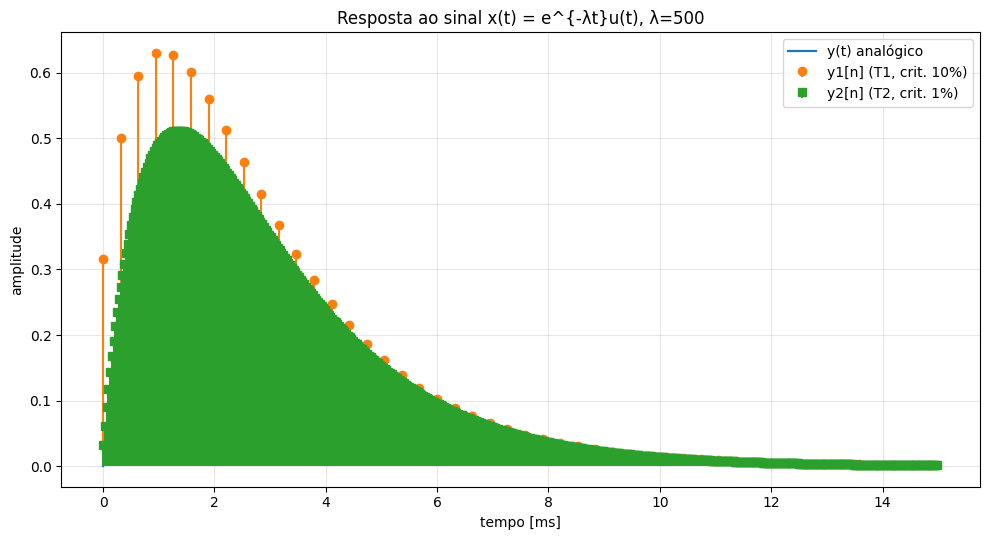

In [30]:
#Resposta da questão 3d

lam = 500

# resposta analógica (fechada)
t_plot = np.linspace(0, 15e-3, 2000)
y_ana = (wc/(wc - lam)) * (np.exp(-lam*t_plot) - np.exp(-wc*t_plot))

# amostragens
M1 = int(np.ceil(15e-3 / T1))
M2 = int(np.ceil(15e-3 / T2))
n1 = np.arange(M1)
n2 = np.arange(M2)

x1 = np.exp(-lam * n1 * T1)
x2 = np.exp(-lam * n2 * T2)

y1 = sps.lfilter(b1, a1, x1)
y2 = sps.lfilter(b2, a2, x2)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(t_plot*1e3, y_ana, label="y(t) analógico", lw=1.6)
ax.stem(n1*T1*1e3, y1, linefmt='C1-', markerfmt='C1o', basefmt=' ',
        label=f"y1[n] (T1, crit. 10%)")
ax.stem(n2*T2*1e3, y2, linefmt='C2-', markerfmt='C2s', basefmt=' ',
        label=f"y2[n] (T2, crit. 1%)")
ax.set_xlabel("tempo [ms]")
ax.set_ylabel("amplitude")
ax.set_title("Resposta ao sinal x(t) = e^{-λt}u(t), λ=500")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()